# Multiclass Image Classification with VGG19

This notebook shows how to train a **multiclass image classifier** using **transfer learning**.

We will:

1. Load images from folders.
2. Prepare and augment the images.
3. load a pretrained VGG19 model.
4. Train a new multiclass classifier.
5. Evaluate the model.
6. Save the model and its results.

The notebook is written as a classroom example, so each step is kept separate and easy to follow.

## Required dataset structure

Arrange the dataset like this:

```text
animals/
├── train/
│   ├── lion/
|   ├── wolf/
|   ├── hyena/
|   ├── cheetah/
|   ├── fox/
│   └── tiger/
├── dev/
│   ├── lion/
|   ├── wolf/
|   ├── hyena/
|   ├── cheetah/
|   ├── fox/
│   └── tiger/
└── test/
│   ├── lion/
|   ├── wolf/
|   ├── hyena/
|   ├── cheetah/
|   ├── fox/
│   └── tiger/
```

The six folders names inside `train`, `dev`, and `test` become the class names.

## 1. Install the required libraries

Run this cell only when the libraries are not already installed.

After installing TensorFlow for the first time, you may need to restart the notebook kernel.

In [53]:
# Remove the first # from the next line when installation is required.
%pip install tensorflow matplotlib seaborn scikit-learn certifi


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## 2. Import the libraries

In [54]:
from pathlib import Path

import os
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

import tensorflow as tf

from sklearn.metrics import (
    auc,
    balanced_accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    fbeta_score,
    jaccard_score,
    log_loss,
    matthews_corrcoef,
    precision_recall_fscore_support,
    roc_curve,
)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 3. Set the notebook variables

These values can be changed in one place without editing the rest of the notebook.

In [55]:
# Location of the dataset
BASE_DIR = Path("./animals_dataset")

# Image and training settings
IMAGE_SIZE = 128
BATCH_SIZE = 32
LEARNING_RATE = 0.0001
EPOCHS = 40

# Model and results settings
MODEL_NAME = "VGG19" # This is just to create a folder name
RESULTS_DIR = Path("results") / "multiclass" / MODEL_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset folder:", BASE_DIR.resolve())
print("Results folder:", RESULTS_DIR.resolve())

Dataset folder: /Users/daryl/Downloads/Week3_Deep Learning/animals_dataset
Results folder: /Users/daryl/Downloads/Week3_Deep Learning/results/multiclass/VGG19


## 4. Load the image datasets

`image_dataset_from_directory()` reads images directly from the class folders.

- The training data is shuffled.
- The validation data is shuffled.
- The test data is not shuffled because prediction order must remain stable.

In [56]:
train_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "train",
    labels="inferred",
    label_mode="categorical",
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

# Use the same class order for every dataset
class_names = train_raw.class_names

val_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "dev",
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_raw = tf.keras.utils.image_dataset_from_directory(
    BASE_DIR / "test",
    labels="inferred",
    label_mode="categorical",
    class_names=class_names,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print("Classes:", class_names)

Found 1160 files belonging to 6 classes.
Found 247 files belonging to 6 classes.
Found 255 files belonging to 6 classes.
Classes: ['cheetah', 'fox', 'hyena', 'lion', 'tiger', 'wolf']


## 5. Inspect one batch

In [57]:
for images, labels in train_raw.take(1):
    label_numbers = np.argmax(labels.numpy(), axis=1)

    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("First five class numbers:", label_numbers[:5])
    print("First five class names:", [
        class_names[label] for label in label_numbers[:5]
    ])

Image batch shape: (32, 128, 128, 3)
Label batch shape: (32, 6)
First five class numbers: [4 4 5 4 4]
First five class names: ['tiger', 'tiger', 'wolf', 'tiger', 'tiger']


## 6. Display sample training images

The label shown above each image comes from its folder name.

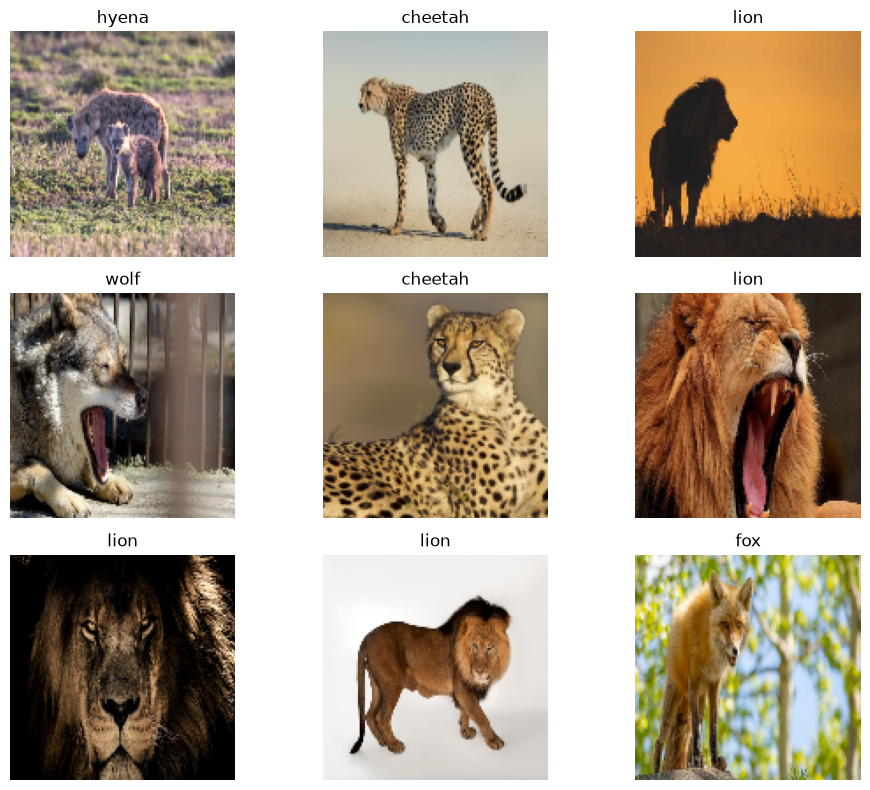

In [58]:
plt.figure(figsize=(10, 8))

for images, labels in train_raw.take(1):
    for index in range(min(9, len(images))):
        plt.subplot(3, 3, index + 1)
        plt.imshow(images[index].numpy().astype("uint8"))

        label_number = np.argmax(labels[index].numpy())
        plt.title(class_names[label_number])
        plt.axis("off")

plt.tight_layout()
plt.show()

## 7. Create image augmentation

Data augmentation creates slightly changed versions of training images.

This helps the model learn patterns instead of memorizing the exact training images.

In [59]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.05),
    tf.keras.layers.RandomContrast(0.1),
])

# VGG19 has its own image preprocessing function
preprocess_input = tf.keras.applications.vgg19.preprocess_input

## 8. Prepare the datasets

Augmentation is applied only to the training dataset.

VGG19 preprocessing is applied to the training, validation, and test datasets.

In [60]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_raw.map(
    lambda images, labels: (
        preprocess_input(data_augmentation(images, training=True)),
        labels,
    ),
    num_parallel_calls=AUTOTUNE,
)

val_ds = val_raw.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE,
)

test_ds = test_raw.map(
    lambda images, labels: (preprocess_input(images), labels),
    num_parallel_calls=AUTOTUNE,
)

# Prefetch prepares the next batch while the current batch is being processed
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

## 9. Load the pretrained VGG19 model

VGG19 was previously trained on the ImageNet dataset.

We remove its original classifier by using `include_top=False`, then freeze the pretrained layers so that only our new classifier is trained.

In [61]:
vgg19_base = tf.keras.applications.VGG19(
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
    include_top=False,
    weights="imagenet",
)

# Freeze the pretrained VGG19 layers
vgg19_base.trainable = False

print("VGG19 trainable:", vgg19_base.trainable)

VGG19 trainable: False


## 10. Build the multiclass classification model

The final `softmax` layer returns one probability for each animal class.

- Each output value represents the probability of one class.
- All class probabilities add up to `1`.
- The class with the highest probability becomes the model's prediction.

For example, if the model returns:

```text
[0.05, 0.10, 0.65, 0.08, 0.07, 0.05]
```

the model predicts the third class because `0.65` is the highest probability.

In [62]:
NUM_CLASSES = len(class_names)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    vgg19_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=LEARNING_RATE
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print("Number of classes:", NUM_CLASSES)
model.summary()

Number of classes: 6


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg19 (Functional)              │ (None, 4, 4, 512)      │    20,024,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,157,254 (76.89 MB)

 Trainable params: 132,870 (519.02 KB)

 Non-trainable params: 20,024,384 (76.39 MB)

## 11. Train the model

In [ ]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
)

Epoch 1/40


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


37/37 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.2302 - loss: 12.1878 - val_accuracy: 0.5304 - val_loss: 3.1525
Epoch 2/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 59s 2s/step - accuracy: 0.4000 - loss: 6.5103 - val_accuracy: 0.7490 - val_loss: 1.4955
Epoch 3/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.5121 - loss: 4.4926 - val_accuracy: 0.8300 - val_loss: 0.9375
Epoch 4/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 65s 2s/step - accuracy: 0.5810 - loss: 3.1719 - val_accuracy: 0.8745 - val_loss: 0.7176
Epoch 5/40
37/37 ━━━━━━━━━━━━━━━━━━━━ 75s 2s/step - accuracy: 0.6371 - loss: 2.7779 - val_accuracy: 0.8988 - val_loss: 0.5610
Epoch 6/40
34/37 ━━━━━━━━━━━━━━━━━━━━ 4s 2s/step - accuracy: 0.7096 - loss: 1.9476

## 12. Plot training accuracy and loss

These graphs help us compare training performance with validation performance.

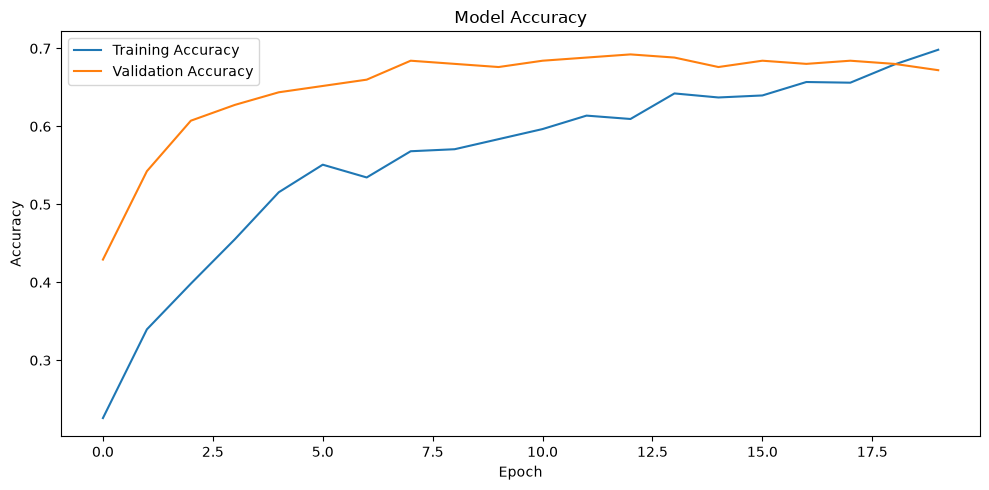

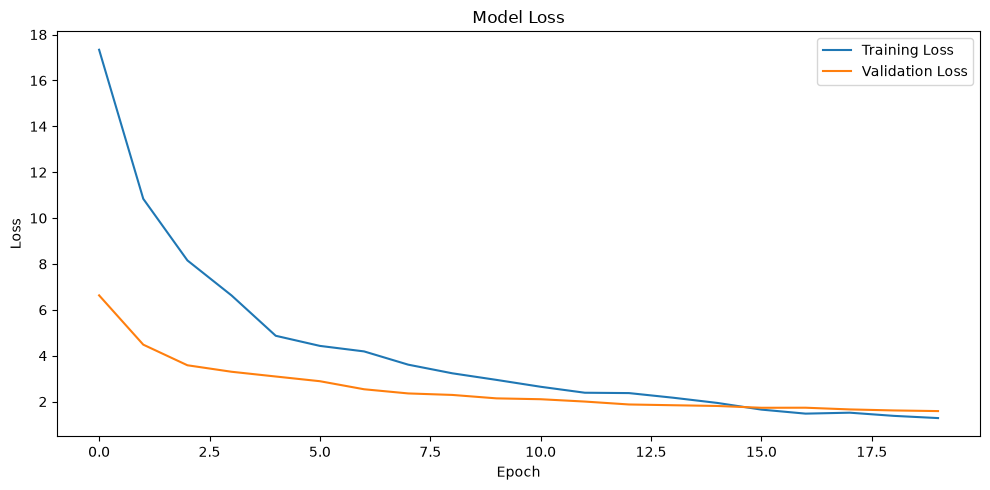

In [ ]:
# Accuracy graph
plt.figure(figsize=(10, 5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_accuracy.png")
plt.show()

# Loss graph
plt.figure(figsize=(10, 5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "training_loss.png")
plt.show()

## 13. Evaluate the model on the test dataset

In [ ]:
test_results = model.evaluate(
    test_ds,
    return_dict=True,
)

print("Test results")
print("-" * 30)

for metric_name, metric_value in test_results.items():
    print(f"{metric_name}: {metric_value:.4f}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.6549 - loss: 1.7409
Test results
------------------------------
accuracy: 0.6549
loss: 1.7409


## 14. Generate predictions

The model returns one probability for every class.

`np.argmax()` selects the class with the highest probability as the final prediction.

In [ ]:
# Convert one-hot encoded labels into class numbers
y_true = np.concatenate([
    np.argmax(labels.numpy(), axis=1)
    for _, labels in test_ds
])

# Predict one probability for each class
y_prob = model.predict(test_ds)

# Select the class with the highest probability
y_pred = np.argmax(y_prob, axis=1)

print("Number of test images:", len(y_true))
print("Probability shape:", y_prob.shape)
print("First five predictions:", y_pred[:5])
print("First five predicted classes:", [
    class_names[prediction] for prediction in y_pred[:5]
])

32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 109ms/step
Number of test images: 255
Probability shape: (255, 6)
First five predictions: [0 0 4 0 0]
First five predicted classes: ['cheetah', 'cheetah', 'tiger', 'cheetah', 'cheetah']


## 15. Classification report

In [ ]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        zero_division=0,
    )
)

              precision    recall  f1-score   support

     cheetah       0.56      0.73      0.63        48
         fox       0.73      0.65      0.69        37
       hyena       0.66      0.51      0.57        45
        lion       0.69      0.70      0.70        44
       tiger       0.67      0.71      0.69        41
        wolf       0.69      0.62      0.66        40

    accuracy                           0.65       255
   macro avg       0.67      0.65      0.66       255
weighted avg       0.66      0.65      0.65       255



## 16. Confusion matrix

The confusion matrix shows how many images from each animal class were classified correctly or incorrectly.

- Rows represent the true classes.
- Columns represent the predicted classes.

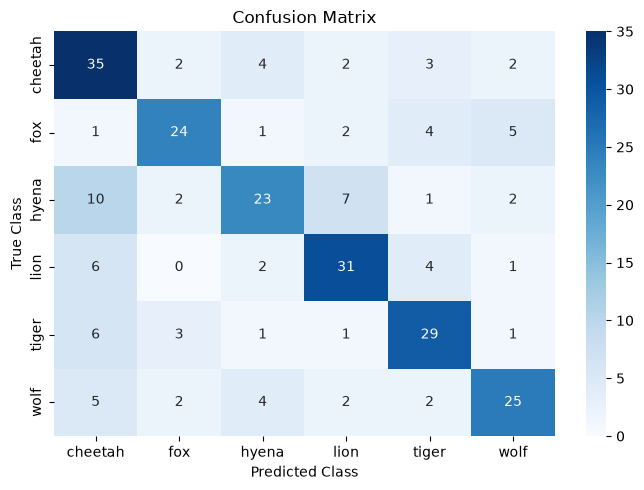

In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "confusion_matrix.png")
plt.show()

## 17. ROC curves

For multiclass classification, each class is compared against all the other classes using the **one-versus-rest** approach.

An AUC closer to `1.0` indicates better separation for that class.

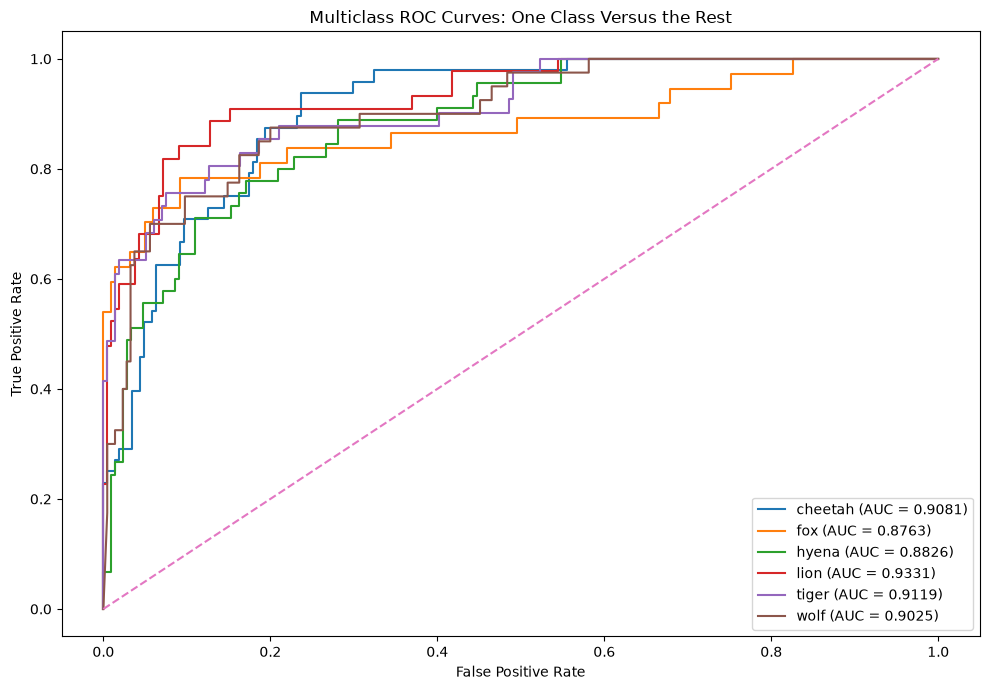

AUC for each class
------------------------------
cheetah: 0.9081
fox: 0.8763
hyena: 0.8826
lion: 0.9331
tiger: 0.9119
wolf: 0.9025
Macro-average AUC: 0.9024


In [ ]:
# Convert the true class numbers back into one-hot form
y_true_one_hot = tf.keras.utils.to_categorical(
    y_true,
    num_classes=NUM_CLASSES,
)

class_auc_scores = {}

plt.figure(figsize=(10, 7))

for class_index, class_name in enumerate(class_names):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        y_true_one_hot[:, class_index],
        y_prob[:, class_index],
    )

    class_auc = auc(false_positive_rate, true_positive_rate)
    class_auc_scores[class_name] = class_auc

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        label=f"{class_name} (AUC = {class_auc:.4f})",
    )

plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("Multiclass ROC Curves: One Class Versus the Rest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "roc_curves.png")
plt.show()

macro_auc = np.mean(list(class_auc_scores.values()))

print("AUC for each class")
print("-" * 30)

for class_name, class_auc in class_auc_scores.items():
    print(f"{class_name}: {class_auc:.4f}")

print(f"Macro-average AUC: {macro_auc:.4f}")

## 18. Calculate additional classification metrics

For multiclass classification, weighted averages give more importance to classes containing more test images.

Macro sensitivity and specificity treat every class equally.

In [ ]:
precision, recall, f1_score, _ = precision_recall_fscore_support(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0,
)

cm = confusion_matrix(y_true, y_pred)

class_sensitivities = []
class_specificities = []

for class_index in range(NUM_CLASSES):
    true_positive = cm[class_index, class_index]
    false_negative = cm[class_index, :].sum() - true_positive
    false_positive = cm[:, class_index].sum() - true_positive
    true_negative = cm.sum() - (
        true_positive
        + false_negative
        + false_positive
    )

    sensitivity = (
        true_positive / (true_positive + false_negative)
        if (true_positive + false_negative) > 0
        else 0.0
    )

    specificity = (
        true_negative / (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else 0.0
    )

    class_sensitivities.append(sensitivity)
    class_specificities.append(specificity)

macro_sensitivity = np.mean(class_sensitivities)
macro_specificity = np.mean(class_specificities)

metrics = {
    "Weighted Precision": precision,
    "Weighted Recall": recall,
    "Macro Sensitivity": macro_sensitivity,
    "Macro Specificity": macro_specificity,
    "Weighted F1-Score": f1_score,
    "Macro-average AUC": macro_auc,
    "Matthews Correlation Coefficient": matthews_corrcoef(
        y_true,
        y_pred,
    ),
    "Cohen's Kappa": cohen_kappa_score(y_true, y_pred),
    "Balanced Accuracy": balanced_accuracy_score(
        y_true,
        y_pred,
    ),
    "Weighted Jaccard Index": jaccard_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0,
    ),
    "Log Loss": log_loss(
        y_true,
        y_prob,
        labels=np.arange(NUM_CLASSES),
    ),
    "Weighted F0.5-Score": fbeta_score(
        y_true,
        y_pred,
        beta=0.5,
        average="weighted",
        zero_division=0,
    ),
}

for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value:.4f}")

Weighted Precision: 0.6623
Weighted Recall: 0.6549
Macro Sensitivity: 0.6543
Macro Specificity: 0.9306
Weighted F1-Score: 0.6541
Macro-average AUC: 0.9024
Matthews Correlation Coefficient: 0.5866
Cohen's Kappa: 0.5846
Balanced Accuracy: 0.6543
Weighted Jaccard Index: 0.4875
Log Loss: 1.6692
Weighted F0.5-Score: 0.6579


## 19. Display sample predictions

Green or red styling is intentionally avoided here; the title directly shows the true and predicted class.

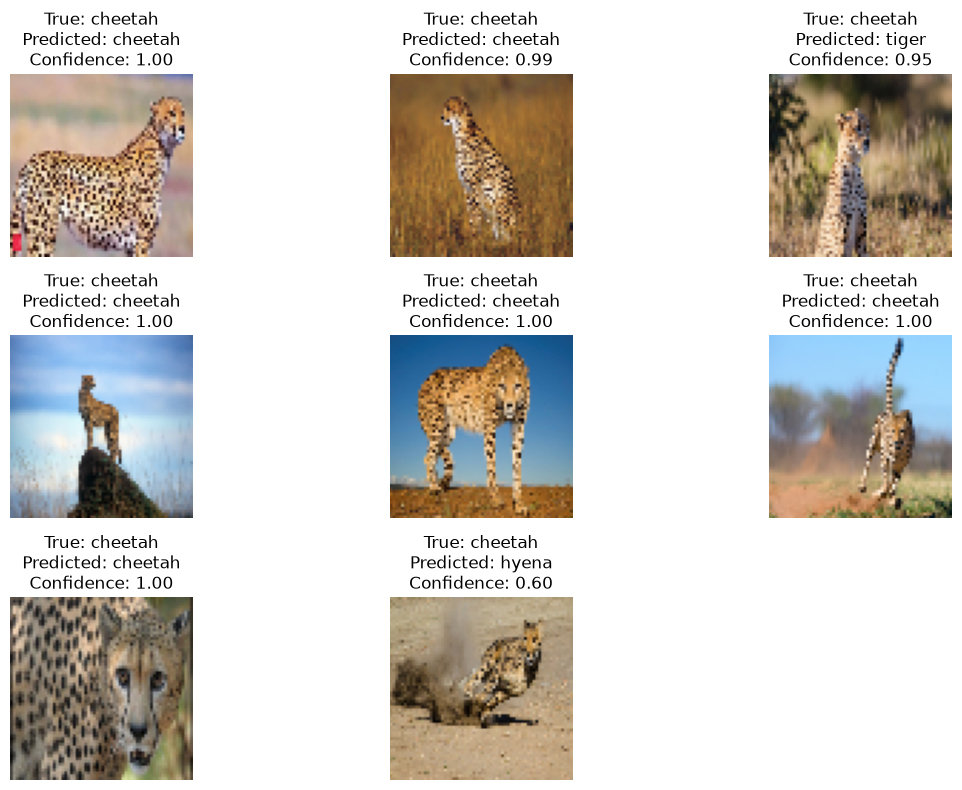

In [ ]:
for images, labels in test_raw.take(1):
    processed_images = preprocess_input(images)
    probabilities = model.predict(
        processed_images,
        verbose=0,
    )

    predictions = np.argmax(probabilities, axis=1)
    true_labels = np.argmax(labels.numpy(), axis=1)

    plt.figure(figsize=(12, 8))

    for index in range(min(9, len(images))):
        true_class = class_names[true_labels[index]]
        predicted_class = class_names[predictions[index]]
        predicted_probability = probabilities[
            index,
            predictions[index],
        ]

        plt.subplot(3, 3, index + 1)
        plt.imshow(images[index].numpy().astype("uint8"))
        plt.title(
            f"True: {true_class}\n"
            f"Predicted: {predicted_class}\n"
            f"Confidence: {predicted_probability:.2f}"
        )
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 20. Save the model and metric files

The model is saved in Keras format.

The notebook also saves the test metrics and the training history as text files.

In [ ]:
# Save the trained model
model_path = RESULTS_DIR / "vgg19_multiclass_classifier.keras"
model.save(model_path)

# Save test metrics
with open(RESULTS_DIR / "testing_metrics.txt", "w", encoding="utf-8") as file:
    for metric_name, metric_value in test_results.items():
        file.write(f"{metric_name}: {metric_value:.4f}\n")

# Save classification metrics
with open(RESULTS_DIR / "classification_metrics.txt", "w", encoding="utf-8") as file:
    for metric_name, metric_value in metrics.items():
        file.write(f"{metric_name}: {metric_value:.4f}\n")

# Save training and validation metrics for every epoch
with open(
    RESULTS_DIR / "training_validation_metrics.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write("Training and Validation Metrics Per Epoch\n")
    file.write("=" * 50 + "\n")

    for epoch_index in range(len(history.history["loss"])):
        file.write(f"Epoch {epoch_index + 1}\n")
        file.write(
            f"  Training Accuracy: "
            f"{history.history['accuracy'][epoch_index]:.4f}\n"
        )
        file.write(
            f"  Validation Accuracy: "
            f"{history.history['val_accuracy'][epoch_index]:.4f}\n"
        )
        file.write(
            f"  Training Loss: "
            f"{history.history['loss'][epoch_index]:.4f}\n"
        )
        file.write(
            f"  Validation Loss: "
            f"{history.history['val_loss'][epoch_index]:.4f}\n"
        )
        file.write("-" * 50 + "\n")

print("Model saved to:", model_path)
print("Other results saved to:", RESULTS_DIR.resolve())

Model saved to: results/multiclass/VGG19/vgg19_multiclass_classifier.keras
Other results saved to: /Users/daryl/Downloads/Week3_Deep Learning/results/multiclass/VGG19


## Terminologies

- **Training data** teaches the model.
- **Validation data** helps us observe learning during training.
- **Test data** measures final performance.
- **Data augmentation** creates useful variations of training images.
- **Transfer learning** reuses features learned by VGG19.
- **Softmax** returns a probability for every class.
- **Categorical cross-entropy** measures multiclass classification error.
- **Argmax** selects the class with the highest probability.
- **Accuracy, precision, recall, F1-score, AUC, and the confusion matrix** describe performance from different viewpoints.